In [1]:
import polars as pl

In [ ]:
# Load data and examine structure
df = pl.read_parquet("../../../data/processed/df_feat_final_result_optimized.parquet")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns[:10]}...")  # Show first 10 columns

In [3]:
# Only fill nulls for columns (not weather_) that actually have nulls
null_counts = df.null_count().to_dict(as_series=False)
cols_to_fill = [col for col in df.columns if (not col.startswith('weather_')) and (null_counts[col][0] > 0)]
df = df.with_columns([pl.col(col).fill_null(0) for col in cols_to_fill])


In [4]:
df.null_count()

ts_start,station_id,dep_last_DT,trip_dur_mean_last_DT,model_FIT_cnt,model_ICONIC_cnt,share_male,share_female,share_other,dep_lag_1,dep_lag_2,dep_lag_3,dep_lag_4,dep_lag_5,dep_lag_6,arr_last_DT,arr_lag_1,arr_lag_2,arr_lag_3,arr_lag_4,arr_lag_5,arr_lag_6,y_arrivals_next_DT,y_departures_next_DT,weather_temperature_2m,weather_relative_humidity_2m,weather_dew_point_2m,weather_apparent_temperature,weather_precipitation,weather_rain,weather_weather_code,weather_pressure_msl,weather_surface_pressure,weather_cloud_cover,weather_cloud_cover_low,weather_cloud_cover_mid,weather_cloud_cover_high,weather_et0_fao_evapotranspiration,weather_vapour_pressure_deficit,weather_wind_speed_10m,weather_wind_speed_100m,weather_wind_direction_10m,weather_wind_direction_100m,weather_wind_gusts_10m,weather_soil_temperature_0_to_7cm,weather_soil_temperature_7_to_28cm,weather_soil_temperature_28_to_100cm,weather_soil_temperature_100_to_255cm,weather_soil_moisture_0_to_7cm,weather_soil_moisture_7_to_28cm,weather_soil_moisture_28_to_100cm,weather_soil_moisture_100_to_255cm,weather_sunshine_duration,weather_is_day,weather_direct_radiation,lat,lon,station_name,hour,dow,month,day,is_holiday_ar,sin_hour,cos_hour,sin_dow,cos_dow,sin_month,cos_month,is_weekend,payday_flag,vacation_season,peak_commute
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,51342,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
# Probabilistic Baseline: Dual Poisson Regression -> Skellam Distribution
import numpy as np
import pandas as pd
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import skellam
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [6]:
# 1. Memory-efficient sampling BEFORE pandas conversion
print(f"Original dataset size: {df.shape[0]:,} rows")

# Sample directly from Polars (much more memory efficient)
n_sample = min(5_000_000, df.shape[0])
sample_fraction = n_sample / df.shape[0]

# Use Polars random sampling (memory efficient)
df_sample = df.sample(fraction=sample_fraction, seed=42)
print(f"Sampled dataset size: {df_sample.shape[0]:,} rows ({sample_fraction*100:.1f}%)")

# Now convert only the sample to pandas
pdf = df_sample.to_pandas()
print(f"Memory usage after sampling: ~{pdf.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Clear original large dataframes
del df, df_sample

Original dataset size: 25,613,290 rows
Sampled dataset size: 5,000,000 rows (19.5%)
Memory usage after sampling: ~1725.8 MB


In [7]:
# Define targets: Δ_t = arrivals - departures 
target_A = 'y_arrivals_next_DT'
target_D = 'y_departures_next_DT'

for col in [target_A, target_D]:
    pdf[col] = pdf[col].astype(np.int64)      # o 'Int64' de pandas para nullables


pdf['delta_t'] = pdf[target_A] - pdf[target_D]

print(f"Target statistics:")
print(f"Arrivals: mean={pdf[target_A].mean():.2f}, std={pdf[target_A].std():.2f}")
print(f"Departures: mean={pdf[target_D].mean():.2f}, std={pdf[target_D].std():.2f}")
print(f"Delta: mean={pdf['delta_t'].mean():.2f}, std={pdf['delta_t'].std():.2f}")


Target statistics:
Arrivals: mean=0.41, std=0.97
Departures: mean=0.41, std=0.99
Delta: mean=0.00, std=0.97


In [8]:
print("Min and max of y_arrivals_next_DT:")
print(pdf['y_arrivals_next_DT'].min(), pdf['y_arrivals_next_DT'].max())

print("Min and max of y_departures_next_DT:")
print(pdf['y_departures_next_DT'].min(), pdf['y_departures_next_DT'].max())

print("Min and max of delta_t:")
print(pdf['delta_t'].min(), pdf['delta_t'].max())



Min and max of y_arrivals_next_DT:
0 29
Min and max of y_departures_next_DT:
0 29
Min and max of delta_t:
-22 17


In [9]:
# 2. Minimal feature set (available at prediction time)
feature_cols = [
 'dep_last_DT', # "station_id",   # removed for generalization
 'trip_dur_mean_last_DT',
 'dep_lag_1',
 'dep_lag_2',
 'dep_lag_3',
 'dep_lag_4',
 'dep_lag_5',
 'dep_lag_6',
 'arr_last_DT',
 'arr_lag_1',
 'arr_lag_2',
 'arr_lag_3',
 'arr_lag_4',
 'arr_lag_5',
 'arr_lag_6',
 'weather_temperature_2m',
 'weather_relative_humidity_2m',
 'weather_apparent_temperature',
 'weather_precipitation',
 'weather_wind_speed_10m',
 'weather_sunshine_duration',
 'weather_is_day',
 'lat',
 'lon',
 #'station_name',
 #'hour',
 #'dow',
 #'month',
 #'day',
 'is_holiday_ar',
 'sin_hour',
 'cos_hour',
 'sin_dow',
 'cos_dow',
 'sin_month',
 'cos_month',
 'is_weekend',
 'payday_flag',
 'vacation_season',
 'peak_commute']

print(f"Selected {len(feature_cols)} features")


Selected 35 features


In [10]:
# 3. Prepare features and targets from sampled data
# Work directly with the already-sampled pdf
X = pdf[feature_cols].copy()

# Encode categorical features if any
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"Encoding column: {col}")
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# Scale features for better convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Get targets (ensure non-negative for Poisson)
y_A = pdf[target_A].values
y_D = pdf[target_D].values
y_delta = pdf['delta_t'].values

print(f"Data shape: X={X_scaled.shape}, y_A={y_A.shape}, y_D={y_D.shape}")
print(f"Feature matrix memory: ~{X_scaled.nbytes / 1e6:.1f} MB")
print(f"Valid samples: {(~np.isnan(y_A) & ~np.isnan(y_D)).sum()}/{len(y_A)}")

# Final memory cleanup
del X  # Keep only the scaled version


Data shape: X=(5000000, 35), y_A=(5000000,), y_D=(5000000,)
Feature matrix memory: ~1400.0 MB
Valid samples: 5000000/5000000


In [11]:
# Geographic Clustering with GMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import seaborn as sns

# 1. Extract unique stations with coordinates
print("Extracting unique stations...")
unique_stations = pdf[['station_id', 'lat', 'lon']].drop_duplicates('station_id')
print(f"Found {len(unique_stations)} unique stations")

# 2. Prepare coordinates for clustering
coords = unique_stations[['lat', 'lon']].values
print(f"Coordinate range: lat=[{coords[:, 0].min():.4f}, {coords[:, 0].max():.4f}], lon=[{coords[:, 1].min():.4f}, {coords[:, 1].max():.4f}]")

# Scale coordinates for GMM
scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)


Extracting unique stations...
Found 398 unique stations
Coordinate range: lat=[-34.6878, -34.5367], lon=[-58.5271, -58.3555]


In [12]:
# 3. Find optimal number of clusters using silhouette score
cluster_range = range(41, 100)  # Test 2 to 14 clusters
silhouette_scores = []
models = {}

print("Testing different numbers of clusters...")
for n_clusters in cluster_range:
    # Fit GMM
    gmm = GaussianMixture(n_components=n_clusters, random_state=42, n_init=5)
    cluster_labels = gmm.fit_predict(coords_scaled)
    
    # Calculate silhouette score
    sil_score = silhouette_score(coords_scaled, cluster_labels)
    silhouette_scores.append(sil_score)
    models[n_clusters] = gmm
    
    print(f"n_clusters={n_clusters:2d}: silhouette_score={sil_score:.4f}")

# Find optimal number of clusters
optimal_n_clusters = cluster_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_n_clusters}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")

# Get the optimal model and final cluster assignments
best_gmm = models[optimal_n_clusters]
final_clusters = best_gmm.predict(coords_scaled)
unique_stations['cluster'] = final_clusters


Testing different numbers of clusters...
n_clusters=41: silhouette_score=0.2029
n_clusters=42: silhouette_score=0.1971
n_clusters=43: silhouette_score=0.1741
n_clusters=44: silhouette_score=0.1678
n_clusters=45: silhouette_score=0.1876
n_clusters=46: silhouette_score=0.1612
n_clusters=47: silhouette_score=0.2347
n_clusters=48: silhouette_score=0.2291
n_clusters=49: silhouette_score=0.1740
n_clusters=50: silhouette_score=0.2036
n_clusters=51: silhouette_score=0.1766
n_clusters=52: silhouette_score=0.1990
n_clusters=53: silhouette_score=0.1718
n_clusters=54: silhouette_score=0.1872
n_clusters=55: silhouette_score=0.1907
n_clusters=56: silhouette_score=0.1168
n_clusters=57: silhouette_score=0.2061
n_clusters=58: silhouette_score=0.1633
n_clusters=59: silhouette_score=0.1629
n_clusters=60: silhouette_score=0.1247
n_clusters=61: silhouette_score=0.1535
n_clusters=62: silhouette_score=0.1712
n_clusters=63: silhouette_score=0.1643
n_clusters=64: silhouette_score=0.1515
n_clusters=65: silhouet

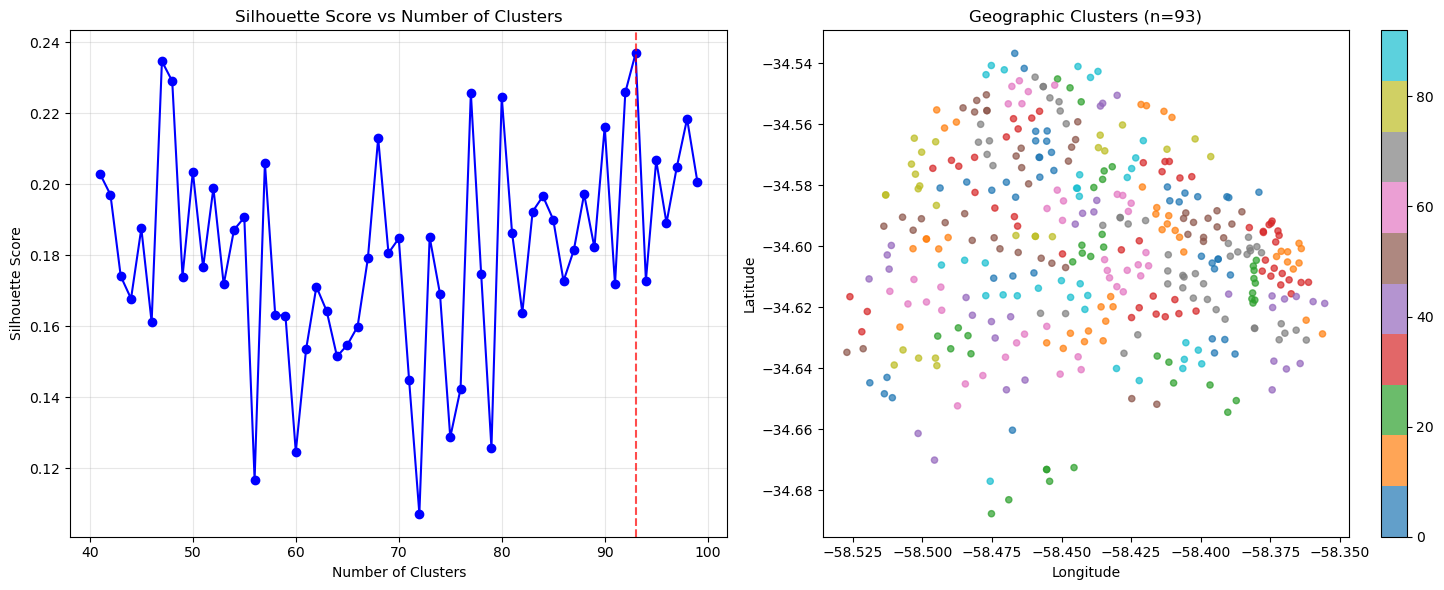


Cluster distribution:
Cluster 0: 3 stations (0.8%)
Cluster 1: 5 stations (1.3%)
Cluster 2: 4 stations (1.0%)
Cluster 3: 4 stations (1.0%)
Cluster 4: 3 stations (0.8%)
Cluster 5: 9 stations (2.3%)
Cluster 6: 5 stations (1.3%)
Cluster 7: 6 stations (1.5%)
Cluster 8: 1 stations (0.3%)
Cluster 9: 2 stations (0.5%)
Cluster 10: 4 stations (1.0%)
Cluster 11: 1 stations (0.3%)
Cluster 12: 8 stations (2.0%)
Cluster 13: 3 stations (0.8%)
Cluster 14: 4 stations (1.0%)
Cluster 15: 2 stations (0.5%)
Cluster 16: 5 stations (1.3%)
Cluster 17: 9 stations (2.3%)
Cluster 18: 6 stations (1.5%)
Cluster 19: 6 stations (1.5%)
Cluster 20: 3 stations (0.8%)
Cluster 21: 4 stations (1.0%)
Cluster 22: 9 stations (2.3%)
Cluster 23: 3 stations (0.8%)
Cluster 24: 5 stations (1.3%)
Cluster 25: 4 stations (1.0%)
Cluster 26: 3 stations (0.8%)
Cluster 27: 2 stations (0.5%)
Cluster 28: 5 stations (1.3%)
Cluster 29: 10 stations (2.5%)
Cluster 30: 8 stations (2.0%)
Cluster 31: 4 stations (1.0%)
Cluster 32: 9 stations (2.

In [13]:
# 4. Visualize clustering results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot silhouette scores
ax1.plot(cluster_range, silhouette_scores, 'bo-')
ax1.axvline(x=optimal_n_clusters, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score vs Number of Clusters')
ax1.grid(True, alpha=0.3)

# Plot geographic clusters
scatter = ax2.scatter(unique_stations['lon'], unique_stations['lat'], 
                     c=unique_stations['cluster'], cmap='tab10', s=20, alpha=0.7)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title(f'Geographic Clusters (n={optimal_n_clusters})')
plt.colorbar(scatter, ax=ax2)

plt.tight_layout()
plt.show()

# Print cluster statistics
print(f"\nCluster distribution:")
cluster_counts = unique_stations['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} stations ({count/len(unique_stations)*100:.1f}%)")


In [14]:
# 5. Add cluster labels to the main dataset
print("Adding cluster labels to the main dataset...")

# Merge cluster assignments back to the main dataset
pdf_clustered = pdf.merge(unique_stations[['station_id', 'cluster']], on='station_id', how='left')

# Verify the merge
print(f"Original dataset shape: {pdf.shape}")
print(f"Clustered dataset shape: {pdf_clustered.shape}")
print(f"Samples with cluster labels: {pdf_clustered['cluster'].notna().sum()}/{len(pdf_clustered)}")

# Check cluster distribution in the full dataset
cluster_dist = pdf_clustered['cluster'].value_counts().sort_index()
print(f"\nCluster distribution in full dataset:")
for cluster_id, count in cluster_dist.items():
    print(f"Cluster {cluster_id}: {count:,} samples ({count/len(pdf_clustered)*100:.1f}%)")


Adding cluster labels to the main dataset...
Original dataset shape: (5000000, 74)
Clustered dataset shape: (5000000, 75)
Samples with cluster labels: 5000000/5000000

Cluster distribution in full dataset:
Cluster 0: 37,516 samples (0.8%)
Cluster 1: 62,746 samples (1.3%)
Cluster 2: 50,634 samples (1.0%)
Cluster 3: 50,329 samples (1.0%)
Cluster 4: 37,843 samples (0.8%)
Cluster 5: 113,164 samples (2.3%)
Cluster 6: 62,817 samples (1.3%)
Cluster 7: 75,524 samples (1.5%)
Cluster 8: 12,558 samples (0.3%)
Cluster 9: 25,214 samples (0.5%)
Cluster 10: 50,475 samples (1.0%)
Cluster 11: 12,597 samples (0.3%)
Cluster 12: 100,540 samples (2.0%)
Cluster 13: 37,751 samples (0.8%)
Cluster 14: 50,283 samples (1.0%)
Cluster 15: 25,004 samples (0.5%)
Cluster 16: 62,796 samples (1.3%)
Cluster 17: 112,503 samples (2.3%)
Cluster 18: 75,347 samples (1.5%)
Cluster 19: 75,195 samples (1.5%)
Cluster 20: 37,528 samples (0.8%)
Cluster 21: 50,199 samples (1.0%)
Cluster 22: 112,988 samples (2.3%)
Cluster 23: 37,741

In [15]:
# 6. Save the clustered dataset using chunked writing
import os
import gc
from pathlib import Path
import polars as pl

def write_parquet_streaming(
    df: pl.DataFrame,
    path: str | Path,
    *,
    compression: str = "snappy",
    row_group_size: int = 10_000,
) -> None:
    """
    Persist a large Polars DataFrame to Parquet using the built-in streaming engine.

    Parameters
    ----------
    df : pl.DataFrame
        DataFrame to write.
    path : str | pathlib.Path
        Destination file path.
    compression : {'snappy', 'zstd', 'gzip', 'lz4', 'uncompressed'}, default 'snappy'
        Parquet compression codec.
    row_group_size : int, default 10_000
        Row-group size (balance between seek-time and file size).

    Notes
    -----
    * The function relies on Polars' streaming sink, which writes the data
      incrementally without reading it back or mmap-locking the file.
    * Works best with Polars ≥ 1.0, but the `engine="streaming"` flag is added
      explicitly for clarity.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    # Lazy frame → streaming sink
    (
        df.lazy()
          .sink_parquet(
              path.as_posix(),
              compression=compression,
              row_group_size=row_group_size,
              engine="streaming",          # explicit; Polars picks streaming automatically on large frames
          )
    )

    print(f"✅ Saved {df.height:,} rows to {path.resolve()}")


# Create output directory if it doesn't exist
output_dir = "../../../data/processed/"
os.makedirs(output_dir, exist_ok=True)

# Convert back to Polars for efficient chunked saving
print("Converting to Polars for chunked saving...")
df_clustered_pl = pl.from_pandas(pdf_clustered)

# Save as parquet using chunked writing
output_file = os.path.join(output_dir, "df_feat_final_clustered_sample.parquet")
print(f"Saving clustered dataset to: {output_file}")
write_parquet_streaming(df_clustered_pl, output_file, row_group_size=100000)
print(f"File size: ~{os.path.getsize(output_file) / 1e6:.1f} MB")

# Clear memory
del df_clustered_pl
gc.collect()

# Also save the station-cluster mapping for future use
mapping_file = os.path.join(output_dir, "station_cluster_mapping.csv")
unique_stations.to_csv(mapping_file, index=False)
print(f"Saved station-cluster mapping to: {mapping_file}")

# Save clustering model for future predictions
import joblib
model_file = os.path.join(output_dir, "geographic_clustering_model.pkl")
joblib.dump({
    'gmm_model': best_gmm,
    'scaler': scaler_geo,
    'n_clusters': optimal_n_clusters,
    'silhouette_score': max(silhouette_scores)
}, model_file)
print(f"Saved clustering model to: {model_file}")


Converting to Polars for chunked saving...
Saving clustered dataset to: ../../../data/processed/df_feat_final_clustered_sample.parquet
✅ Saved 5,000,000 rows to C:\Users\xxx\Documents\GitHub\EcoBici-AI\data\processed\df_feat_final_clustered_sample.parquet
File size: ~549.7 MB
Saved station-cluster mapping to: ../../../data/processed/station_cluster_mapping.csv
Saved clustering model to: ../../../data/processed/geographic_clustering_model.pkl


In [16]:
# 7. Prepare features with cluster information for baseline models
print("Preparing features with cluster information...")

# Update feature columns to include cluster
feature_cols_clustered = feature_cols + ['cluster']
print(f"Updated feature set: {len(feature_cols_clustered)} features (including cluster)")

# Prepare the new feature matrix
X_clustered = pdf_clustered[feature_cols_clustered].copy()

# Handle any missing cluster labels (fill with -1 for unknown)
X_clustered['cluster'] = X_clustered['cluster'].fillna(-1).astype(int)

# Encode categorical features if any
for col in X_clustered.columns:
    if X_clustered[col].dtype == 'object':
        print(f"Encoding column: {col}")
        le = LabelEncoder()
        X_clustered[col] = le.fit_transform(X_clustered[col].astype(str))

# Scale features
scaler_clustered = StandardScaler()
X_clustered_scaled = scaler_clustered.fit_transform(X_clustered)

print(f"Final feature matrix shape: {X_clustered_scaled.shape}")
print(f"Features include cluster: {('cluster' in X_clustered.columns)}")

# Clear some memory
del pdf  # Keep only the clustered version


Preparing features with cluster information...
Updated feature set: 36 features (including cluster)
Final feature matrix shape: (5000000, 36)
Features include cluster: True


✅ Per-cluster baseline function defined


Training per-cluster baselines...
Processing 93 clusters...
  [1/93] Training cluster 0...
    Samples: 37,516
    Raw targets - A: min=0, max=18, mean=0.736
    Raw targets - D: min=0, max=23, mean=0.712
    Clean targets - A: min=0.0, max=18.0, mean=0.736
    Clean targets - D: min=0.0, max=23.0, mean=0.712
      Fold 0 - Lambda_A: 0.041 to 12.264 (mean=0.721)
      Fold 0 - Lambda_D: 0.044 to 12.178 (mean=0.687)
      Fold 0 - y_delta_test: -10.0 to 12.0 (mean=0.030)
      Fold 0 - point_forecast: -4.640 to 3.982 (mean=0.034)
      Fold 0 - MAE: 0.697605, RMSE: 1.325639
      Fold 1 - Lambda_A: 0.039 to 41.948 (mean=0.730)
      Fold 1 - Lambda_D: 0.054 to 81.950 (mean=0.705)
      Fold 1 - y_delta_test: -11.0 to 10.0 (mean=0.015)
      Fold 1 - point_forecast: -40.002 to 1.855 (mean=0.025)
      Fold 1 - MAE: 0.719490, RMSE: 1.449792
  Fold 2 - Lambda_A > 100: 3.075e+02
      Fold 2 – dropped 1 outlier rows
      Fold 2 - Lambda_A: 0.038 to 19.361 (mean=0.753)
      Fold 2 - Lambda

=== PER-CLUSTER BASELINE RESULTS ===
Successful clusters: 93

Aggregated Performance Metrics:
  Average MAE: 0.403 ± 0.243
  Average RMSE: 0.833 ± 0.339
  Average R2: -0.094 ± 0.362
  Average Log-Likelihood: -12571.5 ± 10010.5
  Average Calibration KS: 0.561 ± 0.143
  Average λ_A: 0.363
  Average λ_D: 0.361

Per-Cluster Performance Summary:
    cluster_id  n_samples  mae_mean  rmse_mean  r2_mean
0            0      37516     0.713      1.381   -0.042
1            1      62746     0.332      0.711    0.005
2            2      50634     0.398      0.778    0.004
3            3      50329     0.078      0.308   -0.009
4            4      37843     0.251      0.617   -0.008
..         ...        ...       ...        ...      ...
88          88      50469     0.280      0.759    0.006
89          89      50500     0.479      0.934   -0.006
90          90      37819     0.333      0.681   -0.007
91          91      62597     0.354      0.758   -0.012
92          92      25237     0.277      

Saved cluster baseline results to: ../../../data/processed/cluster_baseline_results.csv


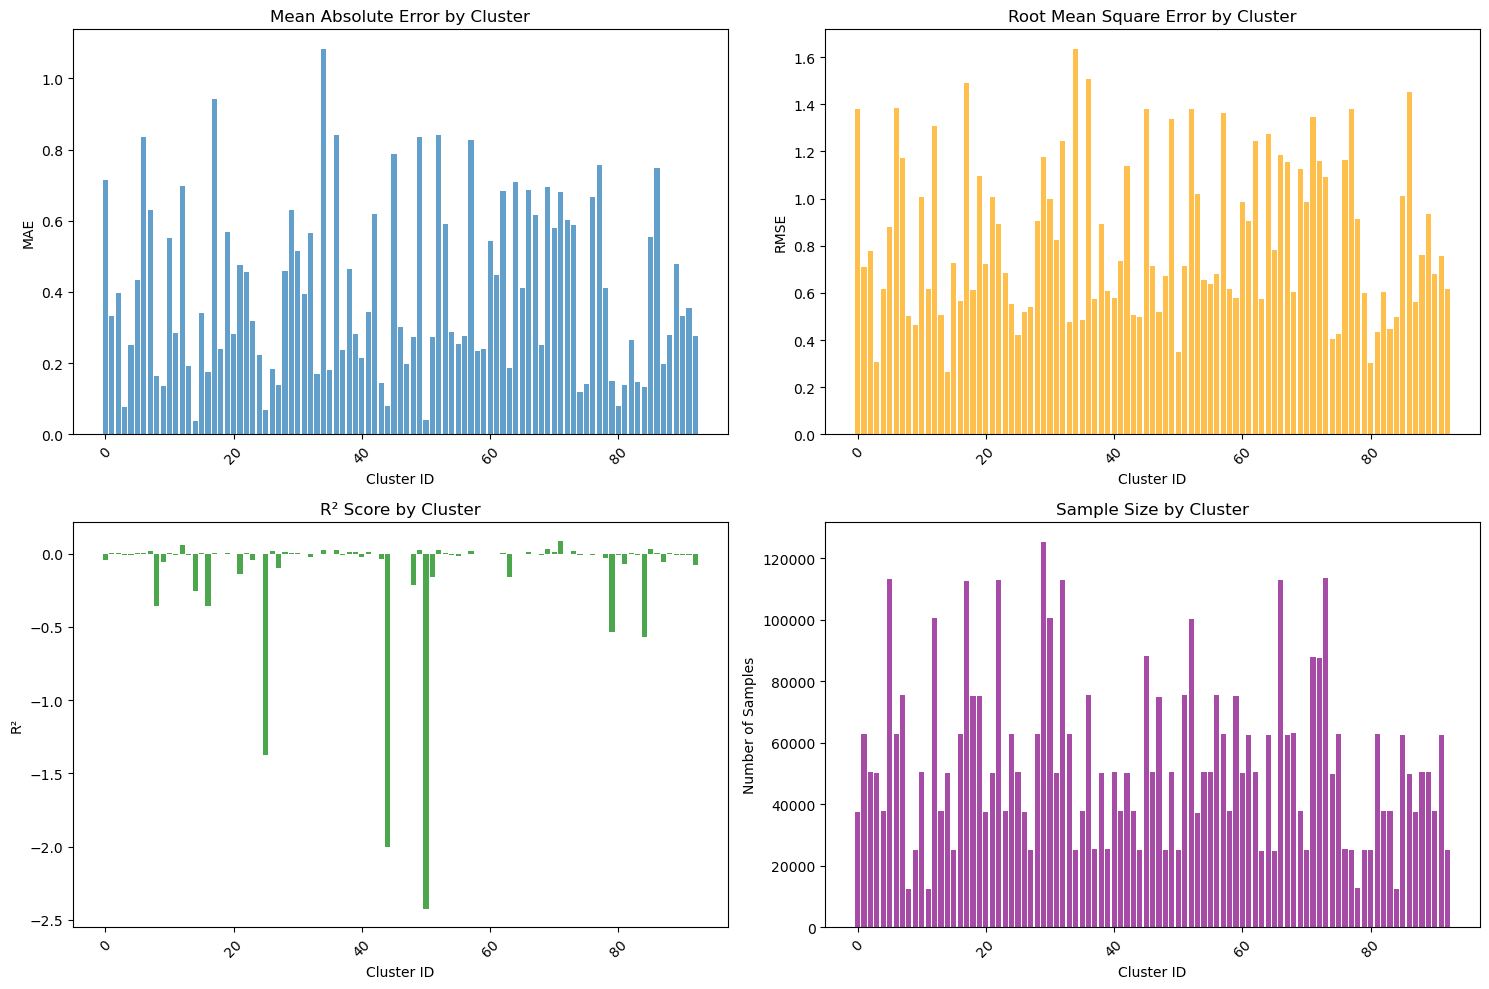


🎯 SUMMARY:
Successfully trained baseline models for 93 clusters
Total samples covered: 5,000,000
Average samples per cluster: 53763
Best performing cluster (lowest MAE): 14 (MAE: 0.038)
Worst performing cluster (highest MAE): 34 (MAE: 1.083)
